# Para esta Tarea

Genera un archivo tipo Notebook de Python que contenga el código fuente de varios ejercicios aplicados a los conceptos vistos:
- Importación de un modelo con datos de tarjetas de crédito (cc general.csv).
- EDA completo siguiendo los modelos anteriores.
- Feature engineering – estandarización, eliminación, nuevas columnas.
- Uso de algoritmo K-Means: elbow plot, análisis.
- Visualización de los resultados del modelo de clustering: bar plots y clases – identificación y perfilamiento de clases.
- Dendogramas y validación de la calidad del fit.
- Silhouette score.
- Visualización simple de los resultados del modelo de clustering.
- Interpretación final de resultados de los clusters generados por el modelo

---

# Importacion de Librerias

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
from sklearn.metrics import mean_squared_error

# Librerias para clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform

---

# Desarrollo 

## EDA

In [115]:
df = pd.read_csv('../../../Archivos-Analisis/files-tarea-m45/CC_GENERAL.csv')
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [116]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [117]:
df.shape

(8950, 18)

In [118]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [119]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [120]:
df.nunique().sort_values()

TENURE                                 7
BALANCE_FREQUENCY                     43
PURCHASES_INSTALLMENTS_FREQUENCY      47
PRC_FULL_PAYMENT                      47
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
ONEOFF_PURCHASES                    4014
CASH_ADVANCE                        4323
INSTALLMENTS_PURCHASES              4452
PURCHASES                           6203
MINIMUM_PAYMENTS                    8636
PAYMENTS                            8711
BALANCE                             8871
CUST_ID                             8950
dtype: int64

In [121]:
df.duplicated().sum()

np.int64(0)

Insights
- La columna CUST_ID se tendra que eliminar ya que no aporta para el analisis
- La columna MINIMUM_PAYMENTS tendra que ser imputada con la media
- Ademas de revisar el valor faltante de la columna CREDIT_LIMIT, para ver su contexto y ser si se imputa o no
- De igual forma no se encontraron valores duplicados

---

# Imputacion de datos

In [122]:
num_min_payments_mean = int(df['MINIMUM_PAYMENTS'].mean())
num_credit_limit_mean = int(df['CREDIT_LIMIT'].mean())

df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(num_min_payments_mean)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(num_credit_limit_mean)

In [123]:
# Corroboramos
df.isnull().sum()


CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

---

In [124]:
df.drop('CUST_ID', axis=1, inplace=True)

---

# Analisis Bivariado y Correlacional

## Correlacional

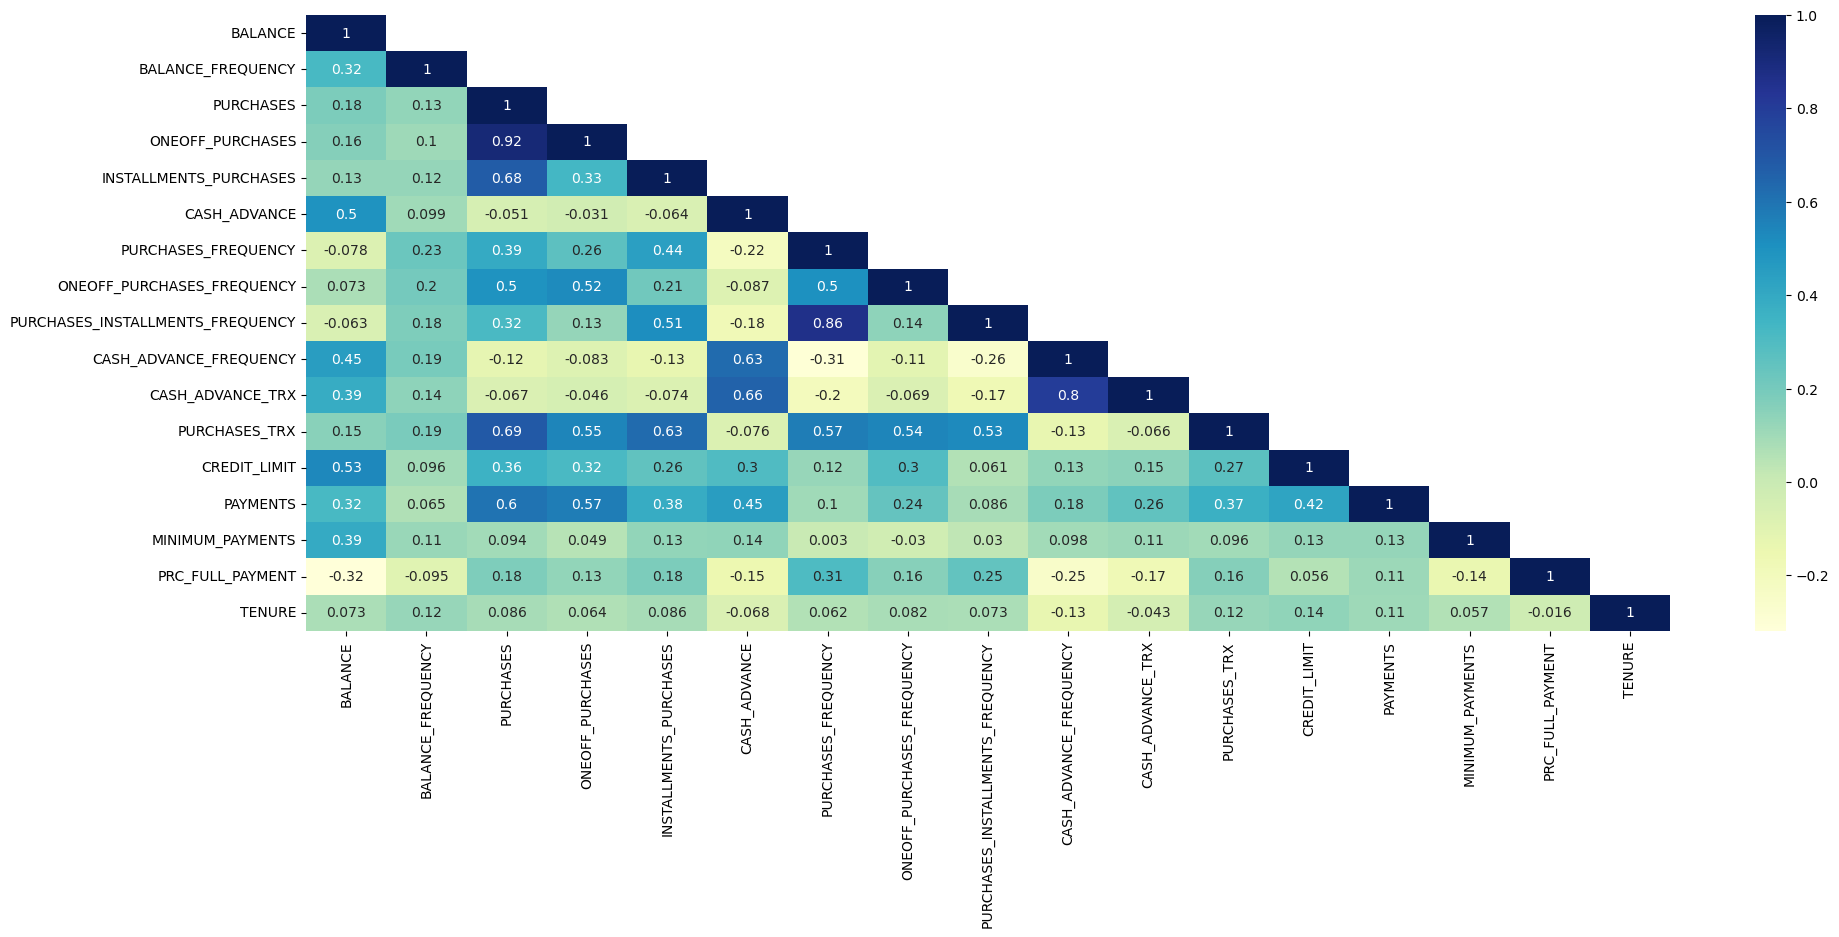

In [125]:
plt.figure(figsize=(22,8))
corr_df = corr = df.corr(method='pearson')
df_lt = corr.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu', annot=True)

Insights 
- En las columnas ONEOFF_PURCHASES con PURCHASES, se cuenta con una correlacion de 0.92, siendo esta demaciado alta
- Al igual que las columnas PURCHASES_INSTALLMENTS_FREQUENCY con PURCHASES_FREQUENCY y CASH_ADVANCE_TRX con CASH_ADVANCE_FREQUENCY, cuentan con una correlacion siperior a 0.80
    por lo que se deberia de observar mas con detenimiento para ver si afecta en algo al analsis
    

In [126]:
# Grafico de distribucion por columnas
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df.select_dtypes(include=numerics).sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
958,192.037218,0.909091,1000.00,1000.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1500.0,1128.431348,157.317690,0.090909,12
7278,919.252125,1.000000,1002.40,1002.40,0.00,196.076296,0.500000,0.500000,0.000000,0.250000,4,18,2000.0,173.632529,2541.357009,0.000000,8
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
7759,1366.778251,1.000000,5065.83,4539.70,526.13,48.245421,1.000000,1.000000,0.666667,0.083333,1,69,1700.0,4366.758829,904.850068,0.000000,12
3802,5218.923199,1.000000,100.01,0.00,100.01,491.329785,0.083333,0.000000,0.083333,0.166667,3,1,6000.0,1299.677915,1252.860717,0.000000,12


In [127]:
cols_num = df.columns[[np.issubdtype(dt, np.number) for dt in df.dtypes]]
cols_num

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

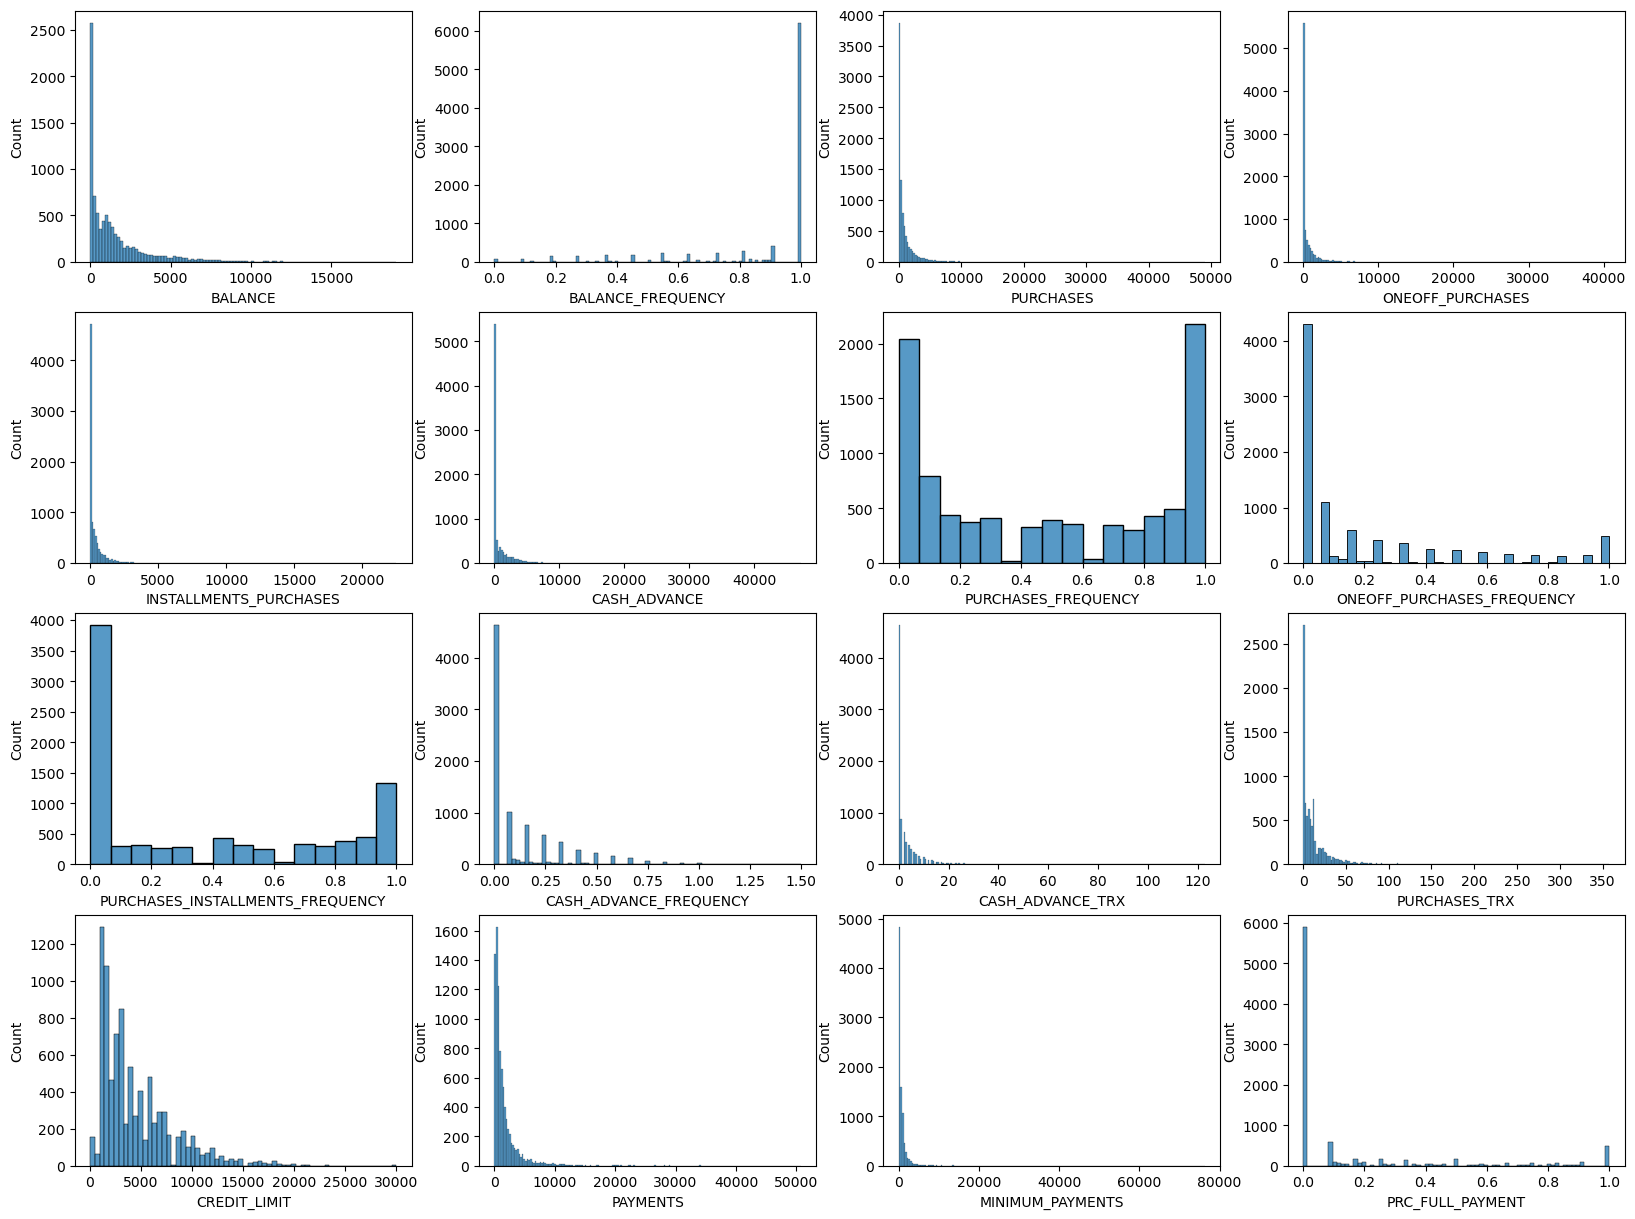

In [128]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20,15))
for i, column in enumerate(cols_num):
    if i < 16:
        sns.histplot(df[column], ax=axes[i//4, i%4], kde=False)

<Axes: xlabel='variable', ylabel='value'>

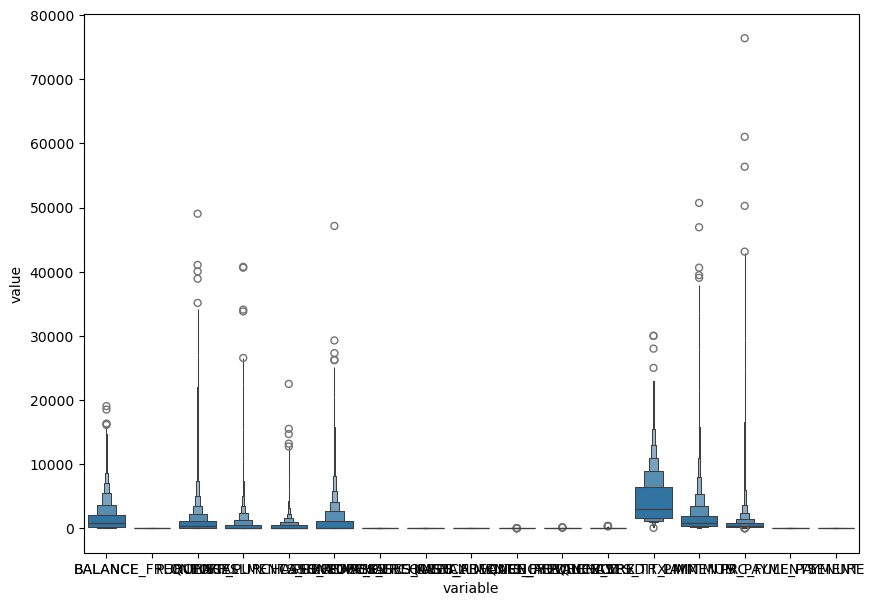

In [129]:
# Buscamos rangos en als variables y potenciales outliers
plt.figure(figsize=(10,7))
sns.boxenplot(x='variable', y='value', data=pd.melt(df[cols_num]))

## Bivariado
En ese caso, no podemos realizar un analsiis Bivariado, debido a que no hay posibles agrupaciones que se puedan realziar, ya que el dataset manejado, unicamente cuenta con valores numericos y 0 categoricos o 'semi-categoricos'

Por lo que este paso, se omitira

---

## Feature Engineering

In [130]:
df2 = df.copy()
df3 = df.copy()

In [131]:
# Escalamiento zscore
from scipy.stats import zscore
df2 = df2.apply(zscore)

In [132]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,8.891708e-17,1.000056,-0.751640,-0.690008,-0.332029,0.235256,8.397489
BALANCE_FREQUENCY,8950.0,2.286439e-16,1.000056,-3.703271,0.049045,0.518084,0.518084,0.518084
PURCHASES,8950.0,0.000000e+00,1.000056,-0.469552,-0.451001,-0.300454,0.050047,22.483510
ONEOFF_PURCHASES,8950.0,3.175610e-17,1.000056,-0.356934,-0.356934,-0.334040,-0.009057,24.201066
INSTALLMENTS_PURCHASES,8950.0,2.540488e-17,1.000056,-0.454576,-0.454576,-0.356156,0.063663,24.426889
CASH_ADVANCE,8950.0,1.016195e-16,1.000056,-0.466786,-0.466786,-0.466786,0.064352,22.011117
PURCHASES_FREQUENCY,8950.0,-1.841854e-16,1.000056,-1.221758,-1.014125,0.024043,1.062211,1.269843
ONEOFF_PURCHASES_FREQUENCY,8950.0,-8.891708e-17,1.000056,-0.678661,-0.678661,-0.399319,0.326973,2.673451
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,4.604634e-17,1.000056,-0.916995,-0.916995,-0.497629,0.970151,1.599199
CASH_ADVANCE_FREQUENCY,8950.0,5.557317e-17,1.000056,-0.675349,-0.675349,-0.675349,0.435149,6.820521


---

# Modelo de Clustering K-Means

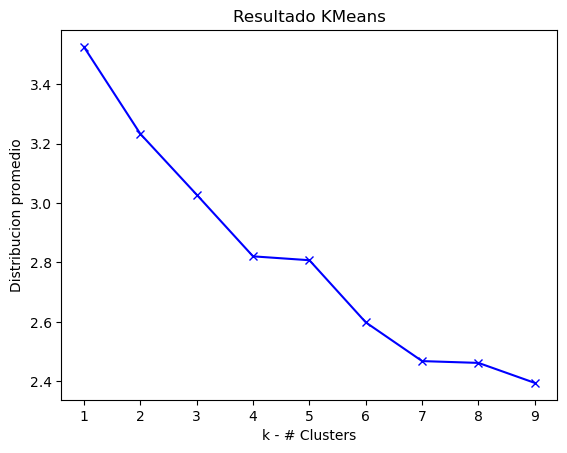

In [133]:
# Buscando el optimo numero de clusters 
from scipy.spatial.distance import cdist
clusters = range (1, 10)
meanDistributions = []

for k in clusters:
    model = KMeans(n_clusters = k)
    model.fit(df2)
    prediction = model.predict(df2)

    meanDistributions.append(sum(np.min(cdist(df2, model.cluster_centers_, 'euclidean'), axis=1)) / df2.shape[0])

plt.plot(clusters, meanDistributions, 'bx-')
plt.xlabel('k - # Clusters')
plt.ylabel('Distribucion promedio')
plt.title('Resultado KMeans')
plt.show()

Insights
- Entre k=4 y k=5 todavía hay una reducción clara, pero después de k=5 la curva se aplana bastante.
- Eso sugiere que el “codo” está alrededor de 4 o 5 clusters.
- Elegir 5 clusters como opcion es totalmente razonable, porque ahí ya se logra un buen balance entre segmentación y estabilidad.
- Si queremos ser más conservador y evitar sobresegmentar, 4 clusters también sería defendible.


In [134]:
# Generamos el numero de clusters
kmeans = KMeans(n_clusters=4, n_init=15, random_state=1)
kmeans.fit(df2)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",15
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [135]:
centroides = kmeans.cluster_centers_
centroides

array([[-2.65551629e-01, -3.68944296e-01, -3.43190301e-01,
        -2.30500433e-01, -3.87798111e-01, -1.82691101e-01,
        -7.97822605e-01, -3.89436941e-01, -7.14245761e-01,
        -1.01500402e-01, -1.64607283e-01, -4.74987456e-01,
        -3.34417132e-01, -2.62060256e-01, -1.19251326e-01,
        -2.58865702e-01, -5.29718263e-02],
       [ 1.45957775e+00,  3.84753065e-01, -2.34638427e-01,
        -1.63914013e-01, -2.53746975e-01,  1.68897201e+00,
        -5.04847568e-01, -2.12939102e-01, -4.50201244e-01,
         1.74594805e+00,  1.61714316e+00, -2.83579688e-01,
         8.38967675e-01,  6.03820830e-01,  4.90911952e-01,
        -4.06367280e-01, -9.71460234e-02],
       [ 9.54484507e-01,  4.62693629e-01,  3.12584465e+00,
         2.71325131e+00,  2.40646962e+00, -1.55090594e-01,
         1.13633760e+00,  1.79865349e+00,  1.06591778e+00,
        -3.19095705e-01, -1.70458235e-01,  3.00325068e+00,
         1.42988163e+00,  1.91909626e+00,  4.77423078e-01,
         4.54702830e-01,  3.2

In [136]:
centroides_df = pd.DataFrame(centroides, columns = list(df2))
centroides_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.265552,-0.368944,-0.343190,-0.230500,-0.387798,-0.182691,-0.797823,-0.389437,-0.714246,-0.101500,-0.164607,-0.474987,-0.334417,-0.262060,-0.119251,-0.258866,-0.052972
1,1.459578,0.384753,-0.234638,-0.163914,-0.253747,1.688972,-0.504848,-0.212939,-0.450201,1.745948,1.617143,-0.283580,0.838968,0.603821,0.490912,-0.406367,-0.097146
2,0.954485,0.462694,3.125845,2.713251,2.406470,-0.155091,1.136338,1.798653,1.065918,-0.319096,-0.170458,3.003251,1.429882,1.919096,0.477423,0.454703,0.324140
3,-0.321688,0.242574,0.109044,0.000926,0.255904,-0.366373,0.983721,0.317153,0.874138,-0.462599,-0.360303,0.296985,-0.077298,-0.138502,-0.091843,0.395041,0.057744


In [137]:
# Generamos un DF con los labels de los clusters y se los convertimos a categoria
df_label = pd.DataFrame(kmeans.labels_, columns = list(['label']))
df_label['label'] = df_label['label'].astype('category')

In [140]:
# Unimos los dos DF
df_label = df3.join(df_label)
df_label.sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,label
7959,40.762516,0.636364,376.00,316.5,59.50,0.000000,0.50,0.416667,0.083333,0.000000,0,7,10000.0,369.351109,141.778284,0.333333,12,0
30,12136.219960,1.000000,3038.01,1013.2,2024.81,3183.583301,1.00,0.166667,1.000000,0.500000,10,64,13000.0,4230.323491,3292.015030,0.000000,12,1
3946,138.596394,1.000000,1333.90,663.9,670.00,0.000000,0.75,0.583333,0.333333,0.000000,0,14,7500.0,1000.797013,142.442556,0.333333,12,3
8226,12.108421,0.272727,0.00,0.0,0.00,625.979655,0.00,0.000000,0.000000,0.166667,2,0,1000.0,680.023540,14.847368,0.090909,12,0
4691,87.462633,0.454545,0.00,0.0,0.00,1251.696029,0.00,0.000000,0.000000,0.083333,1,0,2000.0,2678.249487,114.911590,0.333333,12,0


In [141]:
# Dividimos el cluster
df_label['label'].value_counts()

label
0    3976
3    3367
1    1198
2     409
Name: count, dtype: int64

<Axes: xlabel='label'>

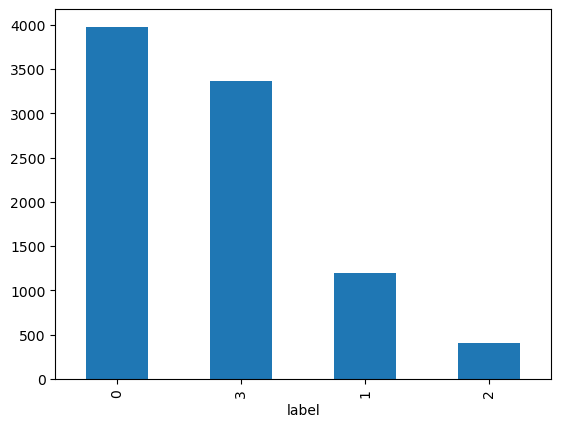

In [162]:
df_label['label'].value_counts().plot(kind='bar')

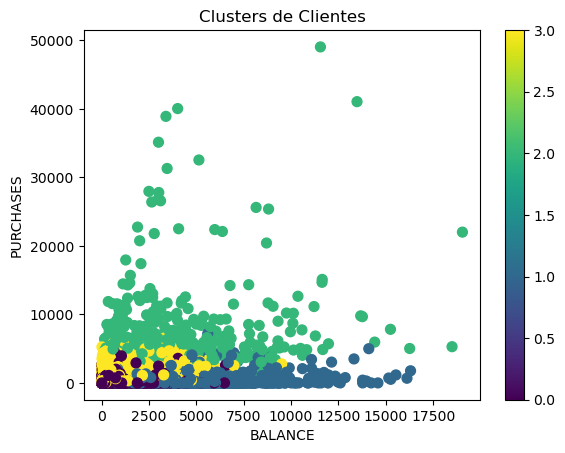

In [146]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_label['BALANCE'], df_label['PURCHASES'], c=df_label['label'], s=50)
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('Clusters de Clientes')
plt.colorbar(scatter)

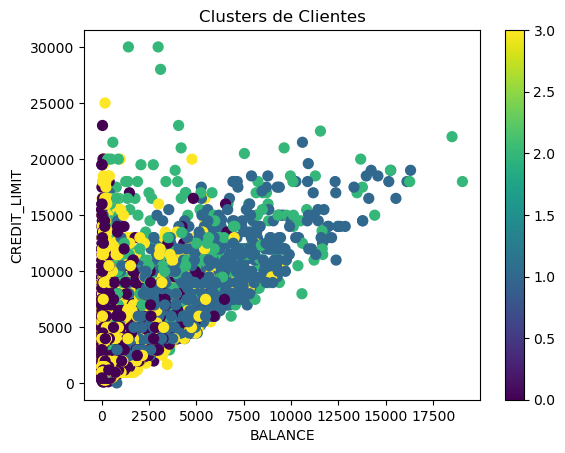

In [148]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_label['BALANCE'], df_label['CREDIT_LIMIT'], c=df_label['label'], s=50)
plt.xlabel('BALANCE')
plt.ylabel('CREDIT_LIMIT')
plt.title('Clusters de Clientes')
plt.colorbar(scatter)

---

### Bonus - Cluster de 5

In [150]:
df4 = df.copy()
df5 = df.copy()

In [151]:
kmeans2 = KMeans(n_clusters=5, n_init=15, random_state=1)
kmeans2.fit(df4)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",15
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [153]:
centroides2 = kmeans2.cluster_centers_
centroides2

array([[7.90260400e+02, 8.48889167e-01, 4.87223513e+02, 2.33774520e+02,
        2.53749993e+02, 4.85559841e+02, 4.46814376e-01, 1.26608461e-01,
        3.44048810e-01, 1.10278884e-01, 2.30506282e+00, 9.21784922e+00,
        2.19487827e+03, 8.76946036e+02, 5.31455594e+02, 1.45636392e-01,
        1.13717664e+01],
       [4.79250250e+03, 9.06825000e-01, 1.17347099e+04, 8.37842694e+03,
        3.35648117e+03, 5.20289245e+03, 7.64045847e-01, 6.19576081e-01,
        6.09182577e-01, 2.06865937e-01, 8.84684685e+00, 8.73243243e+01,
        1.26936937e+04, 1.91257502e+04, 2.45614490e+03, 3.58829901e-01,
        1.18558559e+01],
       [5.47548447e+03, 9.57539047e-01, 1.54283713e+03, 9.57258373e+02,
        5.85653895e+02, 3.83161220e+03, 4.72843139e-01, 2.68157140e-01,
        3.49212557e-01, 3.27962114e-01, 9.64534231e+00, 2.17295174e+01,
        1.09576370e+04, 3.99558017e+03, 1.90174684e+03, 7.01526476e-02,
        1.16711560e+01],
       [1.64809666e+03, 9.06530773e-01, 1.45446602e+03, 9.062

In [154]:
centroides_df4 = pd.DataFrame(kmeans2.cluster_centers_, columns = list(df4))
centroides_df4

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,790.260400,0.848889,487.223513,233.774520,253.749993,485.559841,0.446814,0.126608,0.344049,0.110279,2.305063,9.217849,2194.878275,876.946036,531.455594,0.145636,11.371766
1,4792.502498,0.906825,11734.709910,8378.426937,3356.481171,5202.892453,0.764046,0.619576,0.609183,0.206866,8.846847,87.324324,12693.693694,19125.750204,2456.144903,0.358830,11.855856
2,5475.484469,0.957539,1542.837127,957.258373,585.653895,3831.612201,0.472843,0.268157,0.349213,0.327962,9.645342,21.729517,10957.636976,3995.580175,1901.746841,0.070153,11.671156
3,1648.096659,0.906531,1454.466016,906.279984,548.576625,842.695413,0.579827,0.329392,0.401714,0.117588,2.764919,20.834274,6828.784824,2012.737391,651.893525,0.195622,11.755645
4,4058.147688,0.988636,1027.378750,118.389464,908.989286,922.757849,0.471320,0.039232,0.441153,0.105655,3.017857,18.625000,4267.857143,1624.939145,22760.031552,0.001488,11.910714


In [155]:
df_label2 = pd.DataFrame(kmeans2.labels_, columns = list(['label']))
df_label2['label'] = df_label2['label'].astype('category')

In [156]:
df_label2 = df5.join(df_label2)
df_label2.sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,label
7277,561.003319,1.000000,11577.00,10975.00,602.00,875.583070,1.000000,1.000000,0.500000,0.250000,6,97,5500.0,12148.503510,188.413837,0.666667,12,1
6247,1472.378275,1.000000,0.00,0.00,0.00,2297.002595,0.000000,0.000000,0.000000,0.583333,23,0,4000.0,602.231254,386.832933,0.000000,12,0
1996,163.950974,0.777778,1014.21,264.42,749.79,268.071098,0.777778,0.444444,0.666667,0.111111,1,20,1500.0,938.363310,127.327376,0.600000,9,0
8725,1374.266113,1.000000,1814.30,1596.80,217.50,0.000000,0.666667,0.333333,0.416667,0.000000,0,10,6500.0,2668.399516,413.987806,0.000000,12,3
2825,1589.083369,1.000000,0.00,0.00,0.00,1527.089071,0.000000,0.000000,0.000000,0.428571,4,0,2000.0,287.350882,411.733393,0.000000,7,0


In [157]:
df_label2['label'].value_counts()

label
0    5414
3    2480
2     889
1     111
4      56
Name: count, dtype: int64

<Axes: xlabel='label'>

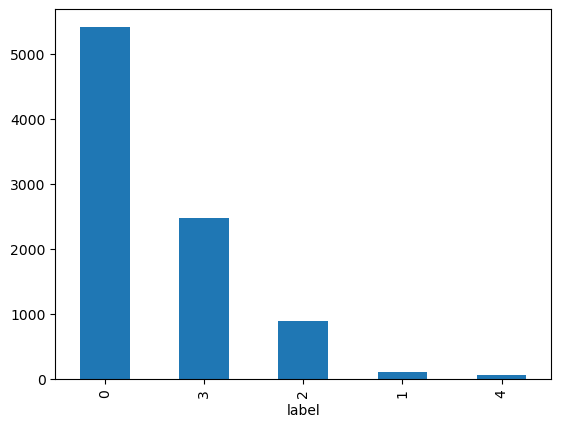

In [163]:
df_label2['label'].value_counts().plot(kind='bar')

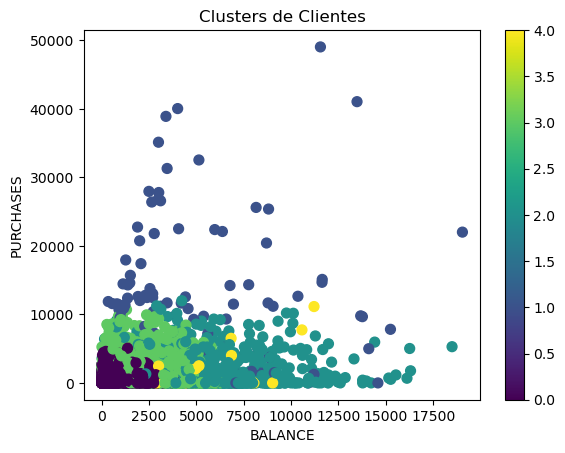

In [164]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_label2['BALANCE'], df_label2['PURCHASES'], c=df_label2['label'], s=50)
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('Clusters de Clientes')
plt.colorbar(scatter)

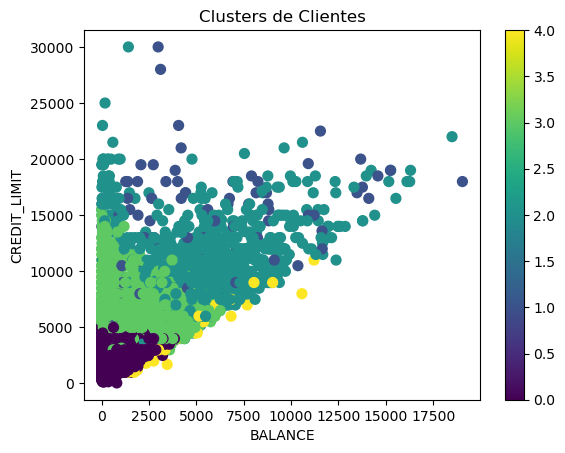

In [165]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_label2['BALANCE'], df_label2['CREDIT_LIMIT'], c=df_label2['label'], s=50)
plt.xlabel('BALANCE')
plt.ylabel('CREDIT_LIMIT')
plt.title('Clusters de Clientes')
plt.colorbar(scatter)

---

# Hierarchical Cluster

In [168]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet

In [171]:
z = linkage(df2, 'average', metric='euclidean')
z.shape

(8949, 4)

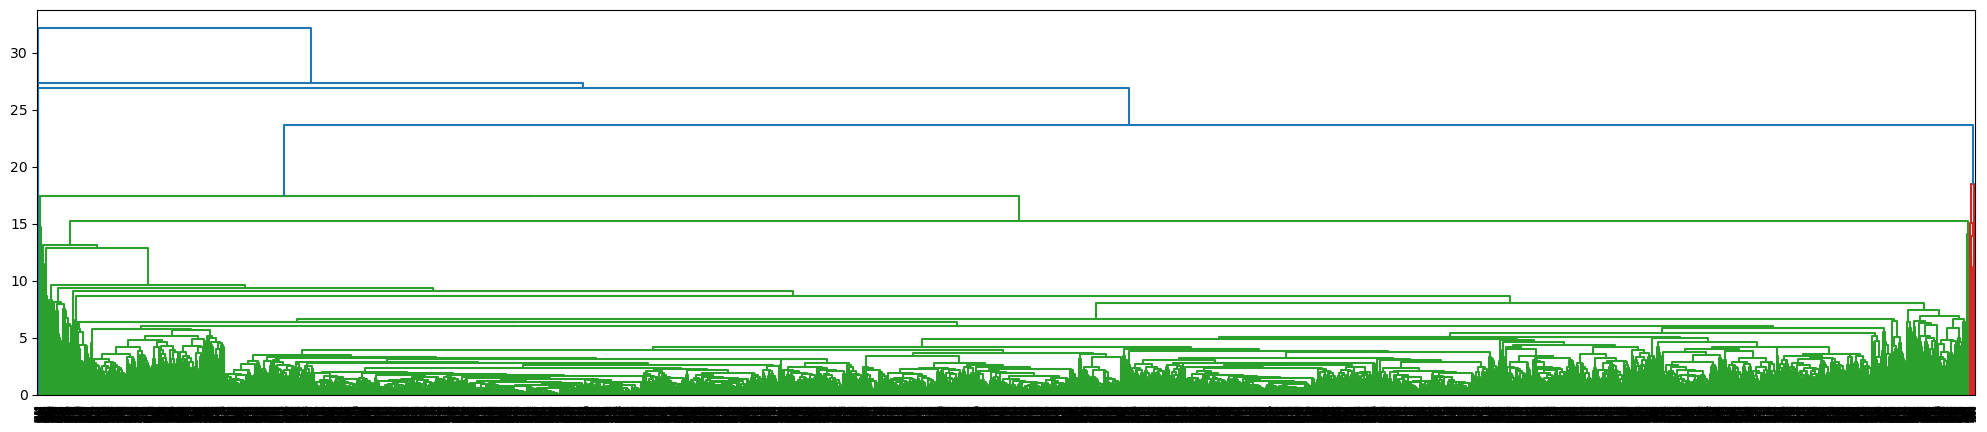

In [172]:
# dendograma
plt.figure(figsize=(25, 5))
dendrogram(z)
plt.show()

In [173]:
# Se  calcula el Coeficiente Cofenetico para calificar la calidad del fit del dendograma con los pares de datos sin ordenar
# El maximo de coeficiente es 1
c, coph_dists = cophenet(z, pdist(df2))
print('Coeficiente Cofenetico: ', format(c, '.4f'))

Coeficiente Cofenetico:  0.8813


---

# Silhouette Score

In [174]:
sil_df = pd.DataFrame({}, columns=['Model', 'n_clusters', 'score'], index=None)


In [175]:
from sklearn.metrics import silhouette_score

result = []

clusters = range(2, 10)

for n_clusters in clusters:
    clusters = KMeans(n_clusters=n_clusters, n_init=15, random_state=1)
    preds = clusters.fit_predict(df2)
    centers = clusters.cluster_centers_

    score = silhouette_score(df2, clusters.labels_, metric='euclidean')

    result.append({'Model':'KMeans', 'n_clusters': n_clusters, 'score': score})

sil_df = pd.DataFrame(result)
sil_df

,Model,n_clusters,score
0,KMeans,2,0.210036
1,KMeans,3,0.250556
2,KMeans,4,0.197607
3,KMeans,5,0.193319
4,KMeans,6,0.202755
5,KMeans,7,0.215038
6,KMeans,8,0.221523
7,KMeans,9,0.215702


C:\Users\RyanHz\AppData\Local\Temp\ipykernel_11532\1921683449.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhuette Score')


Text(0.5, 1.0, 'Silhuette Score')

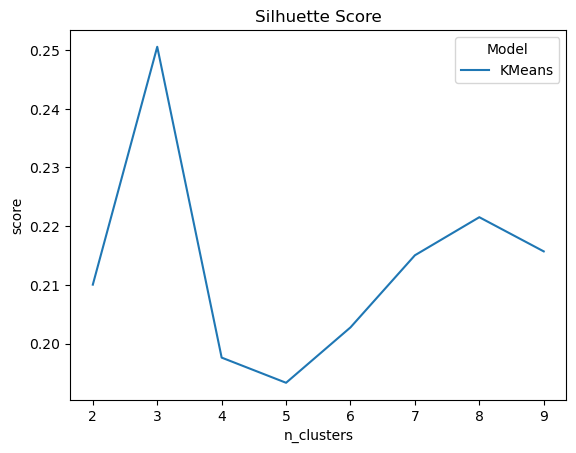

In [ ]:
sns.lineplot(data=sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhuette Score')

---

### Bonus Con el Cluster de 5

In [177]:
z = linkage(df4, 'average', metric='euclidean')
z.shape

(8949, 4)

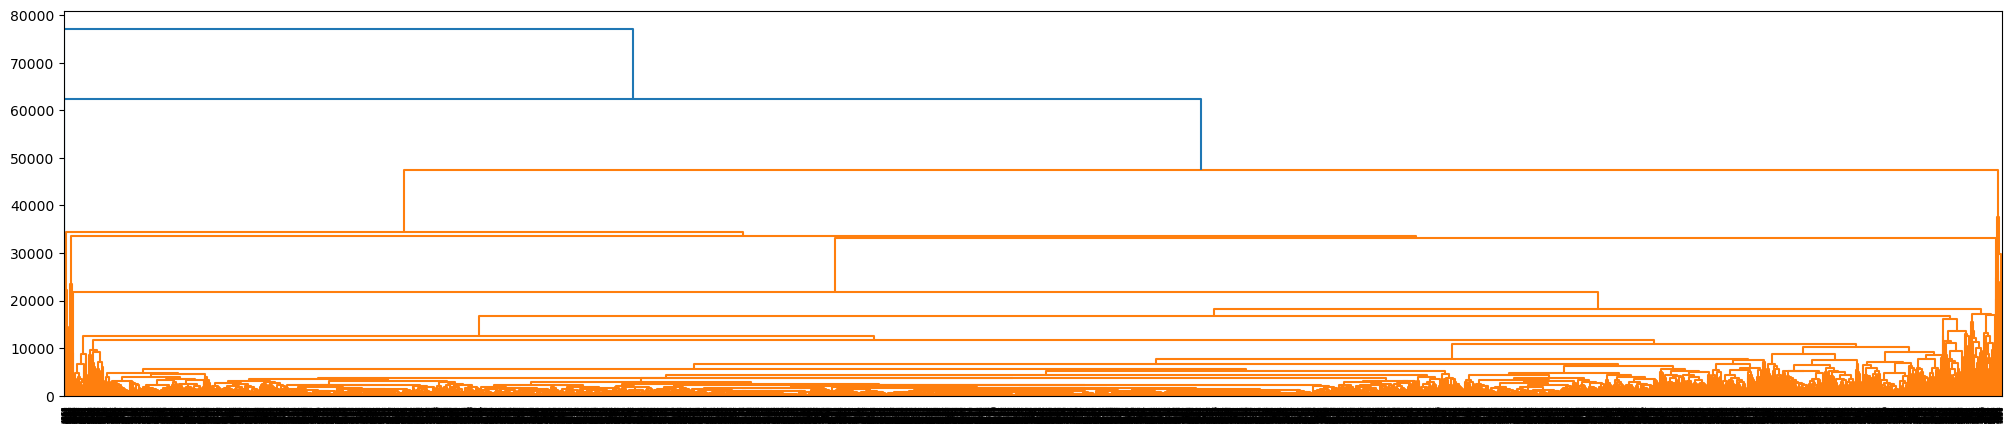

In [178]:
plt.figure(figsize=(25, 5))
dendrogram(z)
plt.show()

In [179]:
c, coph_dists = cophenet(z, pdist(df4))
print('Coeficiente Cofenetico: ', format(c, '.4f'))

Coeficiente Cofenetico:  0.9210


In [180]:
sil_df = pd.DataFrame({}, columns=['Model', 'n_clusters', 'score'], index=None)

In [181]:
result = []

clusters = range(2, 10)

for n_clusters in clusters:
    clusters = KMeans(n_clusters=n_clusters, n_init=15, random_state=1)
    preds = clusters.fit_predict(df4)
    centers = clusters.cluster_centers_

    score = silhouette_score(df4, clusters.labels_, metric='euclidean')

    result.append({'Model':'KMeans', 'n_clusters': n_clusters, 'score': score})

sil_df = pd.DataFrame(result)
sil_df

,Model,n_clusters,score
0,KMeans,2,0.511479
1,KMeans,3,0.467471
2,KMeans,4,0.464451
3,KMeans,5,0.378426
4,KMeans,6,0.372207
5,KMeans,7,0.370041
6,KMeans,8,0.381088
7,KMeans,9,0.352722


C:\Users\RyanHz\AppData\Local\Temp\ipykernel_11532\3375338164.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhuette Score')


Text(0.5, 1.0, 'Silhuette Score')

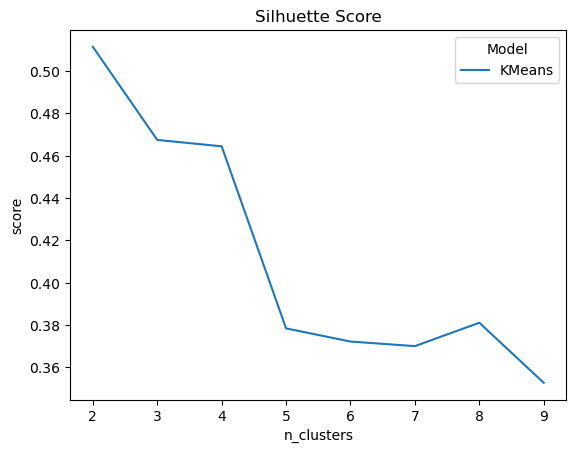

In [182]:
sns.lineplot(data=sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhuette Score')

Insights
- El modelo de cluster con 5, es mucho mejor que el de 4, por lo que se llega a las siguientes conclusiones

---

# Conclusiones

Comparación con las métricas:
- Modelo 1 (k=4): Sc11ore = 0.8813
- Modelo 2 (k=5): Score = 0.9210

